In [174]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [175]:
# Leitura do arquivo

caminho_arquivo = 'tratados_10x10det/nitrogen/nitrogen1E17_array'

df = pl.read_csv(caminho_arquivo, has_header= False).filter(pl.col('column_1').str.contains('TRIG'))

df = df.with_columns(pl.col("column_1").str.split(" ").alias("split_column"))
df = df.with_columns(pl.col("split_column").list.get(0).alias("TRIG"))
df = df.with_columns(pl.col("split_column").list.get(1).cast(pl.Int64).alias("positrons"))
df = df.with_columns(pl.col("split_column").list.get(2).cast(pl.Int64).alias("electrons"))
df = df.with_columns(pl.col("split_column").list.get(3).cast(pl.Int64).alias("muons_plus"))
df = df.with_columns(pl.col("split_column").list.get(4).cast(pl.Int64).alias("muons_minus"))
df = df.with_columns(
    (pl.col("positrons") + pl.col("electrons") + pl.col("muons_plus") + pl.col("muons_minus")).alias("total_particles")
)

df

column_1,split_column,TRIG,positrons,electrons,muons_plus,muons_minus,total_particles
str,list[str],str,i64,i64,i64,i64,i64
"""TRIG1 0 0 0 0""","[""TRIG1"", ""0"", … ""0""]","""TRIG1""",0,0,0,0,0
"""TRIG2 0 0 0 0""","[""TRIG2"", ""0"", … ""0""]","""TRIG2""",0,0,0,0,0
"""TRIG3 0 0 0 0""","[""TRIG3"", ""0"", … ""0""]","""TRIG3""",0,0,0,0,0
"""TRIG4 0 697 0 0""","[""TRIG4"", ""0"", … ""0""]","""TRIG4""",0,697,0,0,697
"""TRIG5 0 0 0 0""","[""TRIG5"", ""0"", … ""0""]","""TRIG5""",0,0,0,0,0
…,…,…,…,…,…,…,…
"""TRIG96 0 0 0 0""","[""TRIG96"", ""0"", … ""0""]","""TRIG96""",0,0,0,0,0
"""TRIG97 0 0 0 0""","[""TRIG97"", ""0"", … ""0""]","""TRIG97""",0,0,0,0,0
"""TRIG98 0 0 0 0""","[""TRIG98"", ""0"", … ""0""]","""TRIG98""",0,0,0,0,0


In [176]:
import re
def formatar_string(s):

    nome_arquivo = s.split('/')[-1]
   
    match = re.match(r'([a-zA-Z]+)([0-9]+(?:\.[0-9]+)?[Ee][0-9]+)', nome_arquivo)

    if match:
        
        palavra = match.group(1).capitalize()
        numero = match.group(2)

        return f'{palavra} {numero}'
    else:
        return nome_arquivo

name = formatar_string(caminho_arquivo)
name

'Nitrogen 1E17'

In [177]:
# Posição dos tanques

numDetectors = 100
gridSize = 10
spacing = 10
area = 1.0

x_det = np.zeros(numDetectors)
y_det = np.zeros(numDetectors)
areas = np.full(numDetectors, area)

index = 0
halfGridSize = gridSize // 2

for i in range(gridSize):
    for j in range(gridSize):
        x_det[index] = (j - halfGridSize + 0.5) * spacing
        y_det[index] = (i - halfGridSize + 0.5) * spacing
        areas[index] = area
        index += 1

#print("x_det:", x_det)
#print("y_det:", y_det)
#print("areas:", areas)

In [178]:
from scipy.spatial import KDTree

df2 = df.group_by('TRIG').agg(pl.col('total_particles')).sort(
    pl.col('TRIG').str.extract(r"TRIG([0-9]*)", 1).cast(int)
)

# Método KDTree 
positions = np.column_stack((x_det, y_det))
tree = KDTree(positions)
d_max = 15  # Distância máxima para considerar como próximos

# Validar simulações com triangulação
num_simulations = len(df2["total_particles"][0])

valid_simulations = []

for sim_idx in range(num_simulations):
    detections = np.array([df2["total_particles"][i][sim_idx] > 0 for i in range(100)])  

    detected_indices = np.where(detections)[0]
    if len(detected_indices) < 3:
        continue
    
    neighbors = []
    for tank in detected_indices:
        neighbors.append(set(tree.query_ball_point(positions[tank], d_max)))
    
    valid = False
    n = len(detected_indices)
    for i in range(n):
        tank_i = detected_indices[i]
        for j in range(i + 1, n):
            tank_j = detected_indices[j]
            if tank_j not in neighbors[i]:  
                continue
            for k in range(j + 1, n):
                tank_k = detected_indices[k]
                if tank_k in neighbors[i] and tank_k in neighbors[j]:
                    valid = True
                    break
            if valid:
                break
        if valid:
            break
    
    if valid:
        valid_simulations.append(sim_idx)


# Atualizar o dataframe
triangulation_particles = [
    [particles[i] for i in valid_simulations] for particles in df2["total_particles"]
]

triangulation_particles = df2.with_columns(
    pl.Series("triangulation_particles", triangulation_particles)
)

print(f"Simulações válidas: {len(valid_simulations)}")
triangulation_particles

Simulações válidas: 682


TRIG,total_particles,triangulation_particles
str,list[i64],list[i64]
"""TRIG1""","[0, 0, … 0]","[0, 490, … 0]"
"""TRIG2""","[0, 0, … 0]","[0, 0, … 0]"
"""TRIG3""","[0, 0, … 0]","[0, 0, … 0]"
"""TRIG4""","[697, 0, … 758]","[697, 0, … 758]"
"""TRIG5""","[0, 0, … 0]","[0, 0, … 0]"
…,…,…
"""TRIG96""","[784, 0, … 0]","[784, 0, … 0]"
"""TRIG97""","[0, 0, … 0]","[0, 560, … 0]"
"""TRIG98""","[0, 0, … 0]","[0, 0, … 0]"


In [179]:
triangulation_particles = triangulation_particles.with_columns(mean_particles = pl.col('triangulation_particles').list.mean())  
trigs = triangulation_particles['mean_particles'].to_list()
triangulation_particles

TRIG,total_particles,triangulation_particles,mean_particles
str,list[i64],list[i64],f64
"""TRIG1""","[0, 0, … 0]","[0, 490, … 0]",90.719941
"""TRIG2""","[0, 0, … 0]","[0, 0, … 0]",108.648094
"""TRIG3""","[0, 0, … 0]","[0, 0, … 0]",138.881232
"""TRIG4""","[697, 0, … 758]","[697, 0, … 758]",155.605572
"""TRIG5""","[0, 0, … 0]","[0, 0, … 0]",163.536657
…,…,…,…
"""TRIG96""","[784, 0, … 0]","[784, 0, … 0]",158.887097
"""TRIG97""","[0, 0, … 0]","[0, 560, … 0]",154.731672
"""TRIG98""","[0, 0, … 0]","[0, 0, … 0]",124.005865


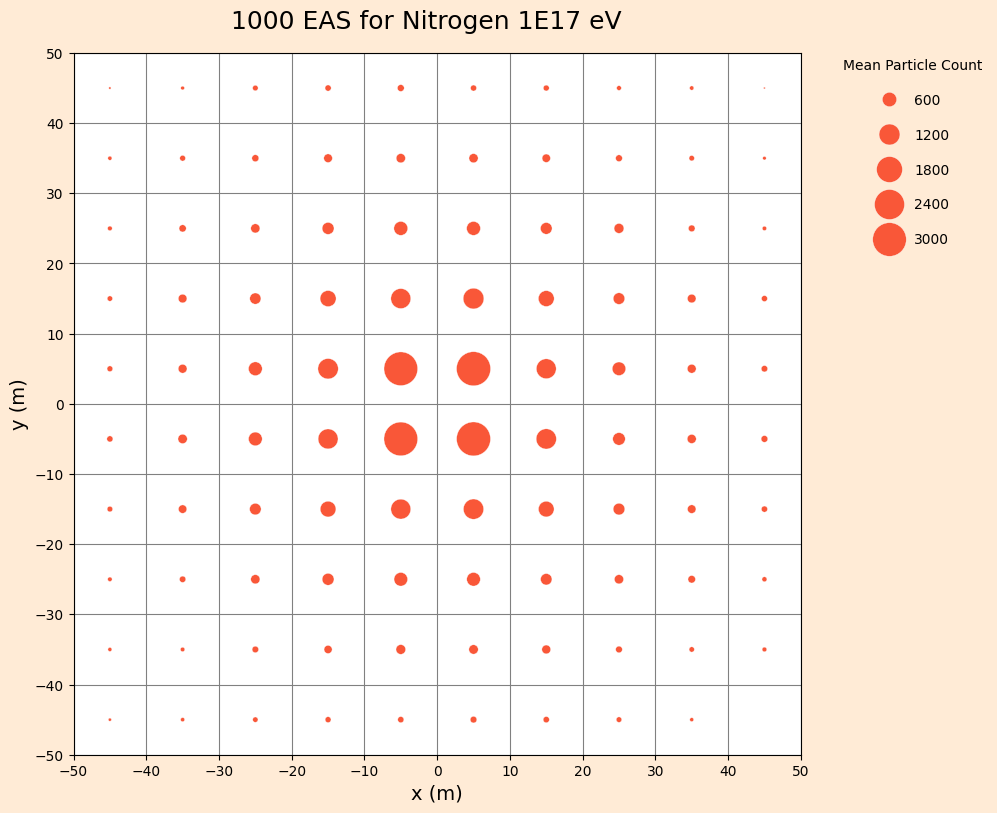

In [180]:
# Plot de partículas por tanque
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('1000 EAS for ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

scatter = sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', size=trigs, sizes=(0, 600), legend = 'brief')
handles, labels = scatter.get_legend_handles_labels()
for handle in handles:
    handle.set_color('#F95738')
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,
           frameon=False, title='Mean Particle Count', labelspacing = 1.5)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


plt.savefig('plots/' + name.split(' ')[0].lower() + '/counts_' + caminho_arquivo.split('/')[-1].split('_')[0] + '.png', bbox_inches = 'tight', dpi = 300)

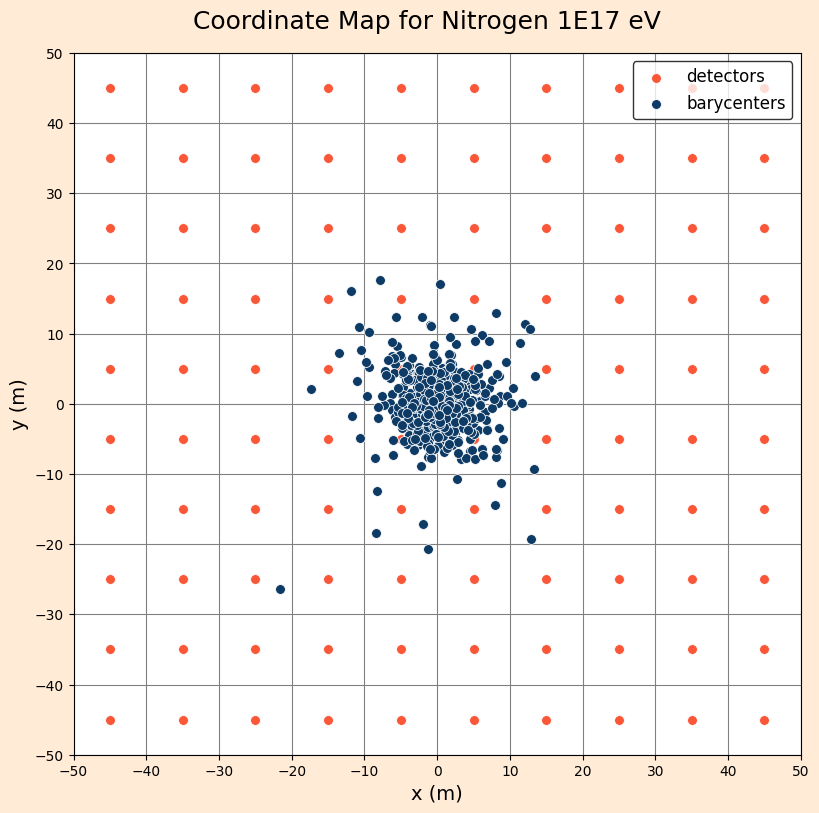

In [181]:
# Posição dos baricentros
x_b = [0] * len(valid_simulations)
y_b = [0] * len(valid_simulations)
rho = []

for i in range(len(valid_simulations)):
        numerator = 0
        numerator1 = 0
        denominator = 0
        for j in range(len(trigs)):
                numerator += (triangulation_particles['triangulation_particles'][j][i]*x_det[j])
                numerator1 += (triangulation_particles['triangulation_particles'][j][i]*y_det[j])
                denominator += (triangulation_particles['triangulation_particles'][j][i])
                rho.append((triangulation_particles['triangulation_particles'][j][i])/1)
                if denominator != 0: 
                    x_b[i] = numerator / denominator
                    y_b[i] = numerator1 / denominator
                else:
                    x_b[i] = 0 
                    y_b[i] = 0 

fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map for ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', s = 50)
sns.scatterplot(x = x_b, y = y_b, ax = ax, color = '#0D3B66',s = 50)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


ax.legend(['detectors', 'barycenters'], edgecolor = 'black', fontsize = 12, loc = 1)

#plt.savefig('plots/' + name.split(' ')[0].lower() + '/map_' + caminho_arquivo.split('/')[-1].split('_')[0] + '.png',bbox_inches = 'tight', dpi = 300)

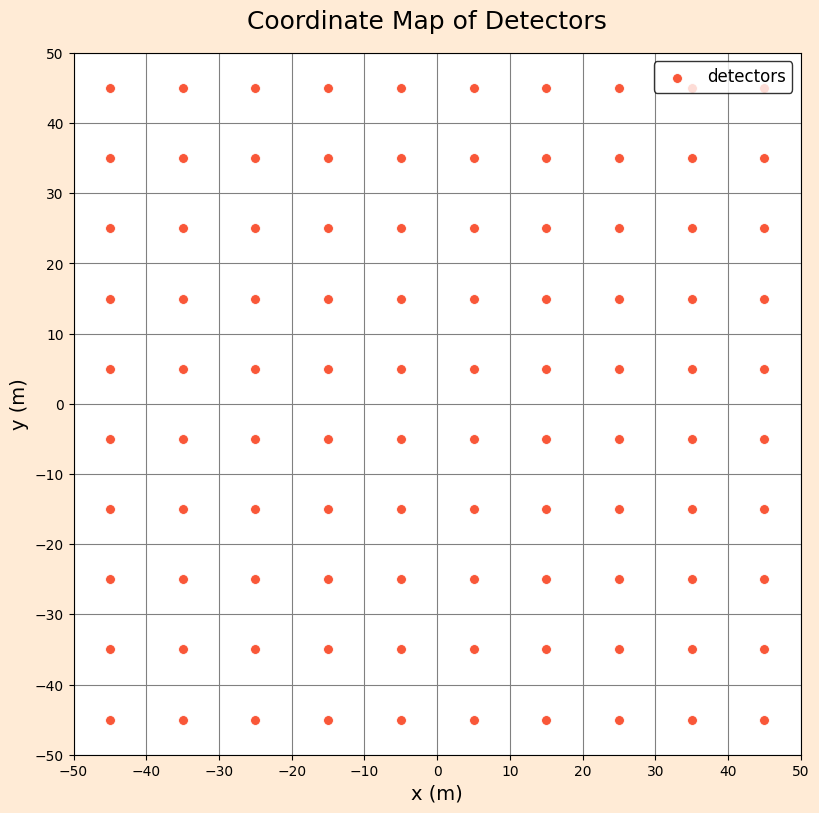

In [182]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of Detectors', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = x_det, y = y_det, ax = ax, color = '#F95738', s = 50)

plt.xticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
plt.yticks(ticks=[-50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50])
ax.set_xlabel('x (m)', size = 14)
ax.set_ylabel('y (m)', size = 14)


ax.legend(['detectors'], edgecolor = 'black', fontsize = 12, loc = 1)

In [183]:
i = 4
eas = 1000
area_detectores = 100
area_total = (np.pi*100**2)
total_particles = [3450445, 6314896, 2.34995e+08, 9.81172e+08, 3.98855e+09]
part = total_particles[i]/eas * (area_detectores/area_total)
part

12695.948965383583

[2.39786670e+06 4.89253868e+00]
[1.40081004 2.91702296 2.637887   3.4317082  3.88504898]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_6688\2610816478.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


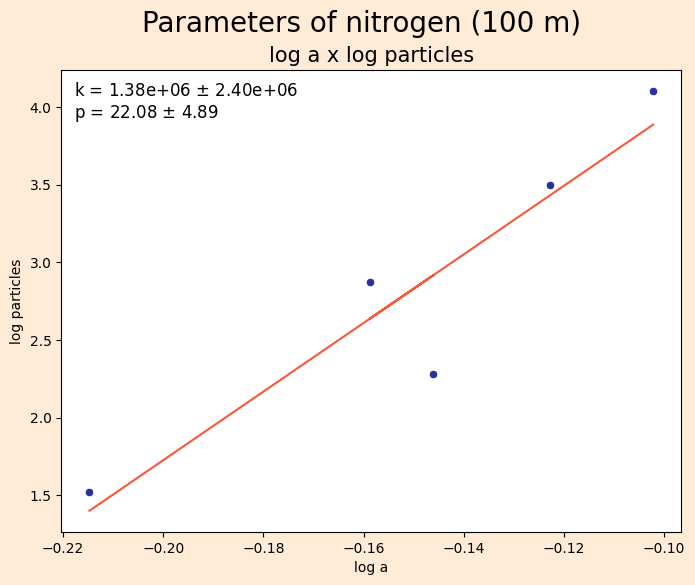

In [184]:
from scipy.optimize import curve_fit

# Fit do nitrogênio

a = [0.6099, 0.7144, 0.6939, 0.7538, 0.7903]

particles = [32.98230496196486, 191.4375073354738, 748.0123170375989, 3123.1674764672225, 12695.948965383583]

E = [1E15, 3.16E15, 1E16, 3.16E16, 1E17]

loga = np.log10(a)
logparticles = np.log10(particles)
#logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of nitrogen (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log a x log particles', size = 15)
ax.set_xlabel('log a')
ax.set_ylabel('log particles')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_nitrogen, cov = curve_fit(power, a, np.log10(particles), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(a,*coefficients_nitrogen))

ax.plot(loga, power(a,*coefficients_nitrogen), color = '#F95738')
sns.scatterplot(x = loga, y = logparticles, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_nitrogen[0],inc[0],coefficients_nitrogen[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)

In [185]:
r_b = [] 

# Estruturação da lista rho para 100 tanques
rho_reshaped = np.array(rho).reshape(len(x_b), 100)


for i in range(len(valid_simulations)):
    #aux = ((x_det[i]-x_b[i])**2 + (y_det[i]-y_b[i])**2)**0.5
    aux = x_b[i]** 2 + y_b[i]**2
    r_b.append(aux)

data = {
    'x_b':x_b,
    'y_b':y_b,
    'r_b':r_b
}

for i in range(100):
    data[f'rho_{i+1}'] = rho_reshaped[:, i].tolist()

df = pl.DataFrame(data, strict=False)

rho_cols = [pl.col(f'rho_{i+1}') for i in range(100)]

df = df.with_columns(
    rho_total=pl.sum_horizontal(rho_cols)        
)

df = df.with_columns(
    particles_total=pl.col('rho_total') * 1
)

df = df.with_columns(
    a=(pl.col("particles_total") / coefficients_nitrogen[0]).pow(1 / coefficients_nitrogen[1])
)

distance_bary = []
for i in range(100):
    x = x_det[i]
    y = y_det[i]
    expr = ((pl.col("x_b") - x)**2 + (pl.col("y_b") - y)**2).sqrt().alias(f"r{i+1}_b")
    distance_bary.append(expr)

df = df.with_columns(distance_bary)

# Reordenar colunas
df = df.select([
    'x_b', 
    'y_b', 
    'r_b', 
    'rho_total', 
    'particles_total', 
    'a',
    *[f'r{i+1}_b' for i in range(100)],
    *[f'rho_{i+1}' for i in range(100)]
])

df

x_b,y_b,r_b,rho_total,particles_total,a,r1_b,r2_b,r3_b,r4_b,r5_b,r6_b,r7_b,r8_b,r9_b,r10_b,r11_b,r12_b,r13_b,r14_b,r15_b,r16_b,r17_b,r18_b,r19_b,r20_b,r21_b,r22_b,r23_b,r24_b,r25_b,r26_b,r27_b,r28_b,r29_b,r30_b,r31_b,…,rho_64,rho_65,rho_66,rho_67,rho_68,rho_69,rho_70,rho_71,rho_72,rho_73,rho_74,rho_75,rho_76,rho_77,rho_78,rho_79,rho_80,rho_81,rho_82,rho_83,rho_84,rho_85,rho_86,rho_87,rho_88,rho_89,rho_90,rho_91,rho_92,rho_93,rho_94,rho_95,rho_96,rho_97,rho_98,rho_99,rho_100
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-6.229453,1.42924,40.848816,7483.0,7483.0,0.789396,60.48826,54.62068,50.080013,47.250363,46.445515,47.767928,51.052561,55.95492,62.093012,69.138493,53.200045,46.420188,40.980763,37.470148,36.44998,38.120731,42.163719,47.983,55.017791,62.861327,46.92185,39.067238,32.416633,27.846493,26.45782,28.715942,33.89977,40.911899,48.973182,57.645135,42.107899,…,0.0,545.0,0.0,0.0,4.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,515.0,784.0,0.0,0.0,0.0,0.0
3.635219,1.035612,14.287308,39706.0,39706.0,0.851386,66.96762,60.099565,54.214881,49.664363,46.838494,46.055838,47.417674,50.751664,55.704821,61.889601,60.530569,52.832239,46.027612,40.568913,37.0558,36.061447,37.785229,41.892949,47.773579,54.859916,55.165547,46.588982,38.701794,32.017565,27.430277,26.071358,28.407945,33.679474,40.76276,48.876356,51.210598,…,0.0,2232.0,1624.0,0.0,1742.0,957.0,0.0,572.0,0.0,0.0,0.0,0.0,1066.0,0.0,549.0,581.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,419.0,0.0,35.0,0.0,560.0,0.0,0.0,110.0
-1.56497,1.661711,5.210415,95513.0,95513.0,0.885921,63.748859,57.403976,52.21605,48.55734,46.787976,47.12127,49.514781,53.693695,59.281636,65.921254,56.839096,49.618366,43.511857,39.045884,36.822282,37.244864,40.230328,45.274482,51.779128,59.265314,50.965171,42.763864,35.497147,29.855433,26.882081,27.458071,31.388614,37.637009,45.253109,53.657649,46.521118,…,730.0,3705.0,966.0,1521.0,3198.0,1131.0,0.0,0.0,0.0,2218.0,2174.0,536.0,1996.0,1340.0,0.0,0.0,0.0,1144.0,945.0,842.0,432.0,824.0,1517.0,0.0,539.0,0.0,0.0,517.0,0.0,0.0,832.0,0.0,0.0,1047.0,0.0,846.0,633.0
0.437248,0.733433,0.72911,10669.0,10669.0,0.802182,64.467747,57.856248,52.33164,48.268577,46.055516,45.960479,47.996048,51.912192,57.324783,63.854411,57.805032,50.325707,43.862648,38.925402,36.144736,36.023561,38.586941,43.361354,49.713802,57.120199,52.218322,43.79507,36.183742,30.008636,26.301583,26.13481,29.568283,35.574406,43.090526,51.459192,48.084139,…,0.0,0.0,1149.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,214.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2.149351,-3.557483,17.275392,59618.0,59618.0,0.867207,62.773749,55.655696,49.543612,44.850669,42.054672,41.540443,43.389186,47.324776,52.883338,59.612586,56.671802,48.669356,41.541776,35.81525,32.245079,31.571476,33.967206,38.868806,45.473036,53.148942,51.796166,42.893541,34.595792,27.456908,22.602981,21.631175,24.998415,31.335822,39.229411,47.916173,48.51796,…,0.0,1765.0,1222.0,0.0,0.0,967.0,0.0,705.0,0.0,0.0,515.0,2899.0,801.0,1224.0,617.0,0.0,0.0,0.0,0.0,0.0,647.0,0.0,1597.0,0.0,0.0,0.0,180.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
-7.071458,4.065138,66.530866,26421.0,26421.0,0.83582,62.015821,56.456985,52.238112,49.701605,49.108845,50.528287,53.800901,58.617115,64.632773,71.545961,54.448685,48.021749,42.982759,39.861595,39.120019,40.887713,44.869079,50.543678,57.411607,65.09625,47.78448,40.30863,34.149888,30.127131,29.13886,31.472247,36.495637,43.282337,51.135016,59.634042,42.450604,…,682.0,2462.0,0.0,0.0,0.0,0.0,0.0,302.0,628.0,0.0,

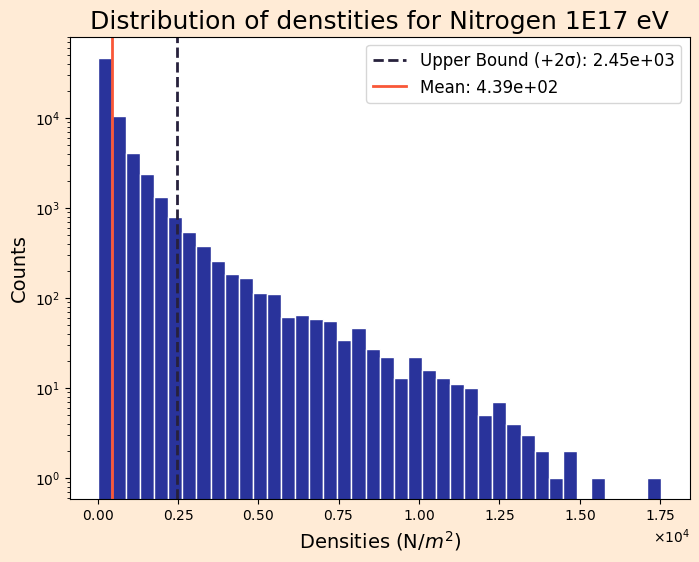

In [186]:
rho_columns = [f"rho_{i+1}" for i in range(100)] 
values = df.select(rho_columns).to_numpy().flatten()  

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#FFEBD6')
plt.hist(values, color='#29339B', bins=40, edgecolor='white')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
ax.set_yscale('log')


plt.title('Distribution of denstities for ' + str(name) + ' eV', size=18)  

# Calcula a média e o desvio padrão dos dados
mean = values.mean()
std = values.std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2e}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2e}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Densities (N/$m^2$)', size=14)
ax.set_ylabel('Counts', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/densities_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')


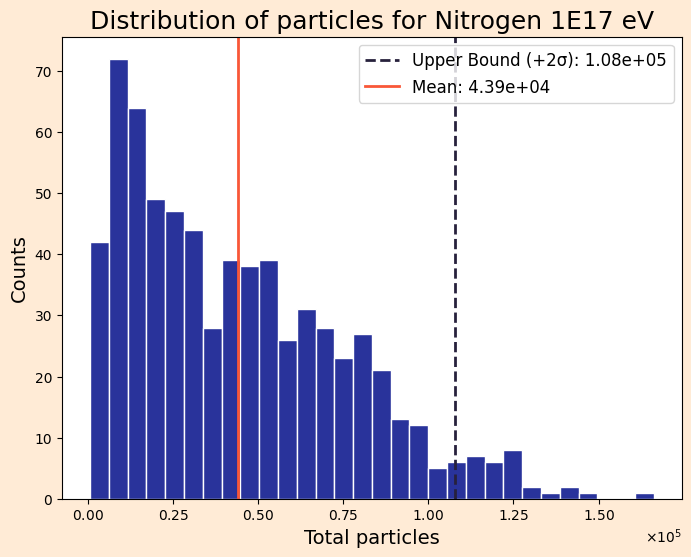

In [187]:
values = df.select('particles_total').to_numpy().flatten()  

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#FFEBD6')
plt.hist(values, color='#29339B', bins=30, edgecolor='white')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)


plt.title('Distribution of particles for ' + str(name) + ' eV', size=18)  

# Calcula a média e o desvio padrão dos dados
mean = values.mean()
std = values.std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2e}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2e}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Total particles', size=14)
ax.set_ylabel('Counts', size=14)
ax.legend(loc='upper right', fontsize=12)

#plt.savefig('plots/' + name.split(' ')[0].lower() + '/densities_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')


In [188]:
# Modelagem NKG
def model(r, C, a, b):
    r0 = 78
    return C/(r0**2)*(r/r0)**(-a)*(1+r/r0)**(-b)


parameters = []
uncertainties = []
r_squared_list = []
rmse_list = []

x_cols = [f"r{i+1}_b" for i in range(100)]  
y_cols = [f"rho_{i+1}" for i in range(100)] 

x = df.select(x_cols).to_numpy()
y = df.select(y_cols).to_numpy()

a_std = df['a'].std()

#for i in range(len(x)):
#    print(f"Linha {i}: x = {x[i]}, y = {y[i]}")

for i in range(len(x)):
    r = x[i].flatten()  
    rho = y[i].flatten()
    a_fixed = df['a'][i]

    try:
        
        def current_model(r, C, b):
            return model(r, C, a_fixed, b)
        
        popt, pcov = curve_fit(current_model, r, rho, p0= [1E5, 3] , bounds= ([0, 2.5], [np.inf, 4.0]))
        perr = np.sqrt(np.diag(pcov))

        # Cálculo das métricas
        y_pred = current_model(r, *popt)

        # R²
        ss_res = np.sum((rho - y_pred)**2)
        ss_tot = np.sum((rho - np.mean(rho))**2)
        r_sq = 1 - (ss_res/ss_tot) if ss_tot != 0 else np.nan

        # RMSE
        rmse = np.sqrt(np.mean((rho - y_pred)**2))

        parameters.append([popt[0], a_fixed, popt[1]])
        uncertainties.append([perr[0], a_std, perr[1]])
        #parameters.append(popt)
        #uncertainties.append(perr)
        r_squared_list.append(r_sq)
        rmse_list.append(rmse)
    except RuntimeError:
        parameters.append([np.nan, np.nan])
        uncertainties.append([np.nan, np.nan])
        r_squared_list.append(np.nan)
        rmse_list.append(np.nan)


# Cria DataFrame com todos os parâmetros
parameters_df = pl.DataFrame({
    'C': [p[0] for p in parameters],
    'a': [p[1] for p in parameters],
    'b': [p[2] for p in parameters],
    'C_err': [e[0] for e in uncertainties],
    'a_err': [e[1] for e in uncertainties],
    'b_err': [e[2] for e in uncertainties],
    'R_2': r_squared_list,
    'RMSE': rmse_list
})

# Filtra valores válidos para estatísticas
valid = parameters_df.filter(
    pl.all_horizontal(
        pl.col('C').is_not_nan(),
        pl.col('a').is_not_nan(),
        pl.col('b').is_not_nan()
    )
)
print(parameters_df)

print("\nEstatísticas dos parâmetros:")
print(f"C: Média = {valid['C'].mean():.2e} ± {valid['C'].std():.2e}")
print(f"a: Média = {valid['a'].mean():.2f} ± {valid['a'].std():.2f}")
print(f"b: Média = {valid['b'].mean():.2f} ± {valid['b'].std():.2f}")
print(f"R² Médio = {valid['R_2'].mean():.3f} ± {valid['R_2'].std():.3f}")
print(f"RMSE Médio = {valid['RMSE'].mean():.3e} ± {valid['RMSE'].std():.3e}")

shape: (682, 8)
┌───────────────┬──────────┬──────────┬──────────────┬──────────┬──────────┬──────────┬────────────┐
│ C             ┆ a        ┆ b        ┆ C_err        ┆ a_err    ┆ b_err    ┆ R_2      ┆ RMSE       │
│ ---           ┆ ---      ┆ ---      ┆ ---          ┆ ---      ┆ ---      ┆ ---      ┆ ---        │
│ f64           ┆ f64      ┆ f64      ┆ f64          ┆ f64      ┆ f64      ┆ f64      ┆ f64        │
╞═══════════════╪══════════╪══════════╪══════════════╪══════════╪══════════╪══════════╪════════════╡
│ 369837.753638 ┆ 0.789396 ┆ 2.5      ┆ 139989.59875 ┆ 0.035883 ┆ 2.11967  ┆ 0.063824 ┆ 227.218694 │
│               ┆          ┆          ┆ 2            ┆          ┆          ┆          ┆            │
│ 2.1664e6      ┆ 0.851386 ┆ 2.5      ┆ 275268.54963 ┆ 0.035883 ┆ 0.737695 ┆ 0.491392 ┆ 489.035206 │
│               ┆          ┆          ┆ 1            ┆          ┆          ┆          ┆            │
│ 5.3677e6      ┆ 0.885921 ┆ 2.546979 ┆ 546835.54737 ┆ 0.035883 ┆ 0.587206 

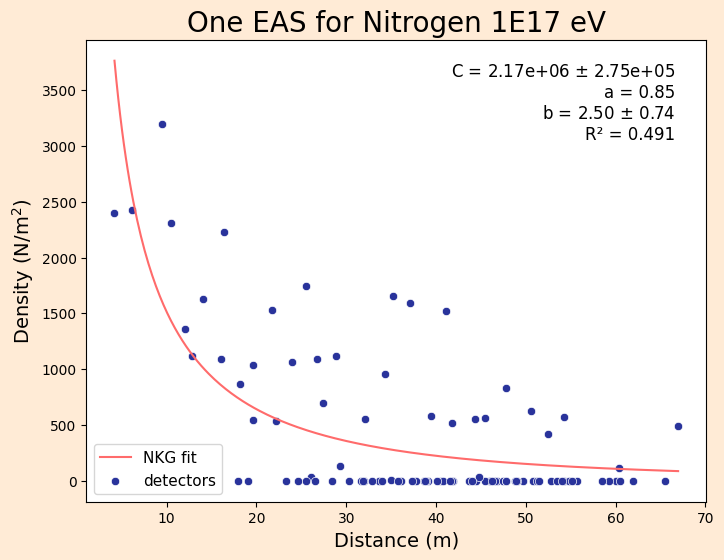

In [189]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.title('One EAS for ' + str(name) + ' eV', size = 20)
#fig.tight_layout()


#ax.set_title('log C x log E', size = 15)
ax.set_xlabel('Distance (m)', size = 14)
ax.set_ylabel('Density (N/m$^2$)', size = 14)
ax.set_facecolor('white')

i = 1

C = parameters_df['C'][i]
a = parameters_df['a'][i]
b = parameters_df['b'][i]
C_err = parameters_df['C_err'][i]
b_err = parameters_df['b_err'][i]

r_smooth = np.linspace(min(x[i]), max(x[i]), 300)
rho_fit = model(r_smooth, C, a, b)

sns.lineplot(x=r_smooth, y=rho_fit, color='#FF6B6B', ax=ax, label='NKG fit')

sns.scatterplot(x = x[i], y = y[i], color = '#29339B', ax = ax, label = 'detectors')

textstr = f'C = {C:.2e} $\pm$ {C_err:.2e}\na = {a:.2f}\nb = {b:.2f} $\pm$ {b_err:.2f}\nR² = {parameters_df["R_2"][i]:.3f}'

ax.text(0.95, 0.95, textstr, transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='right',
        fontsize = 12
        )

ax.legend(
    loc='lower left',
    fontsize=11,
    frameon=True,
    facecolor='white',
)

plt.show()


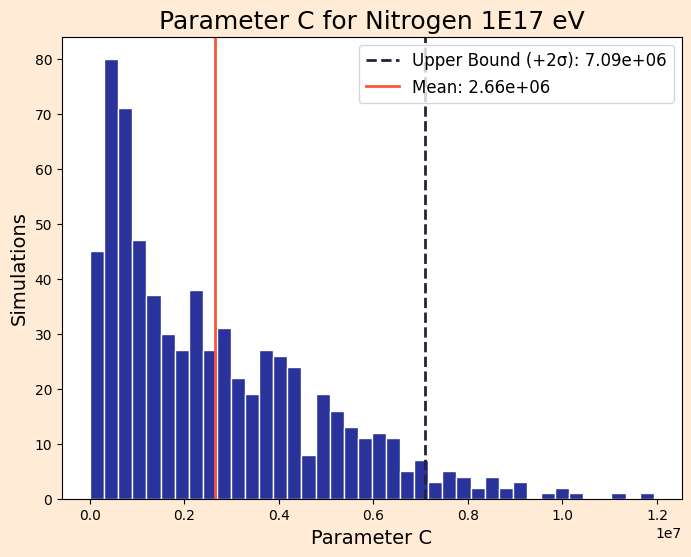

In [190]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['C'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('C')
plt.title('Parameter C for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = parameters_df['C'].mean()
std = parameters_df['C'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2e}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2e}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Parameter C', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/par_c_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

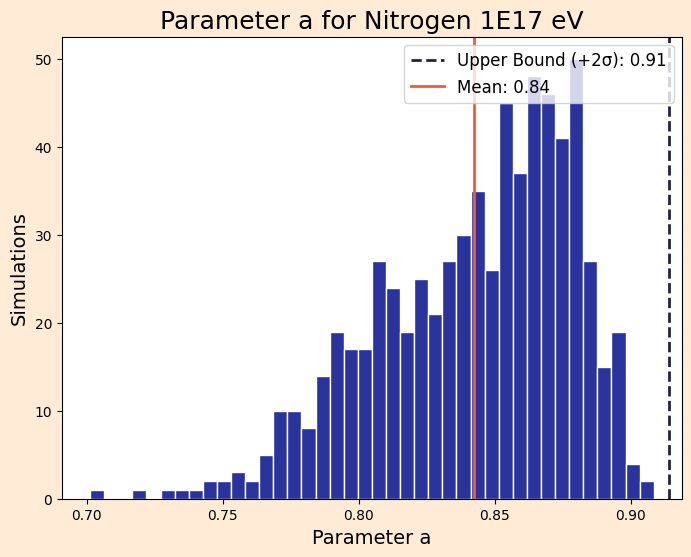

In [191]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['a'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('a')
plt.title('Parameter a for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = parameters_df['a'].mean()
std = parameters_df['a'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Parameter a', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/par_a_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

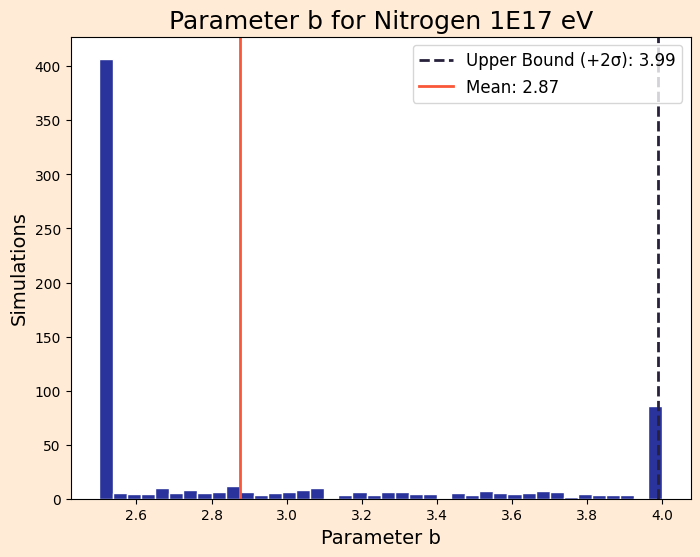

In [192]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['b'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('a')
plt.title('Parameter b for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = parameters_df['b'].mean()
std = parameters_df['b'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Parameter b', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/par_b_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

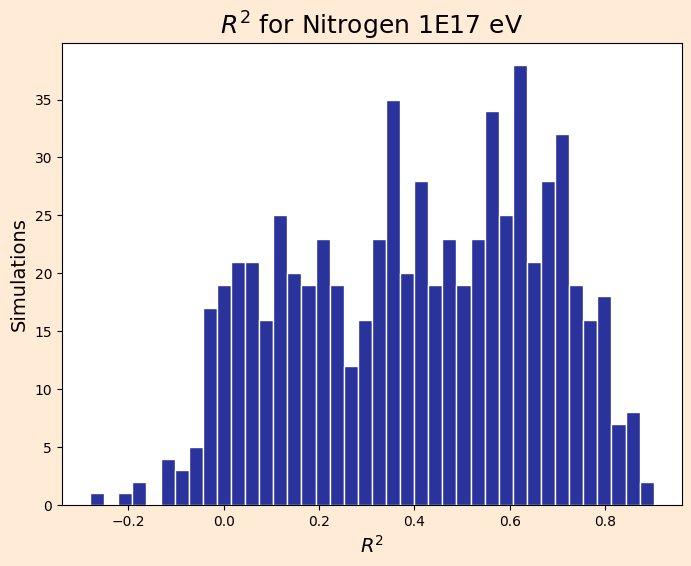

In [193]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['R_2'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('$R^2$')
plt.title('$R^2$ for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

ax.set_xlabel('$R^2$', size=14)
ax.set_ylabel('Simulations', size=14)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/rsquared_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

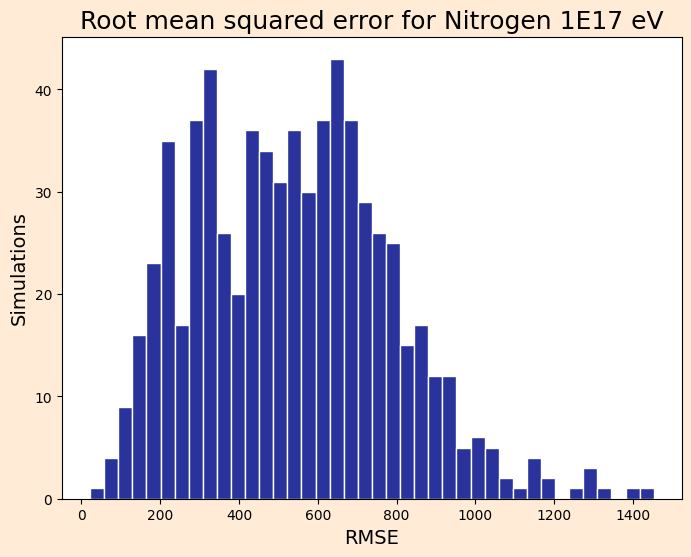

In [194]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['RMSE'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('RMSE')
plt.title('Root mean squared error for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

ax.set_xlabel('RMSE', size=14)
ax.set_ylabel('Simulations', size=14)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/rmse_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

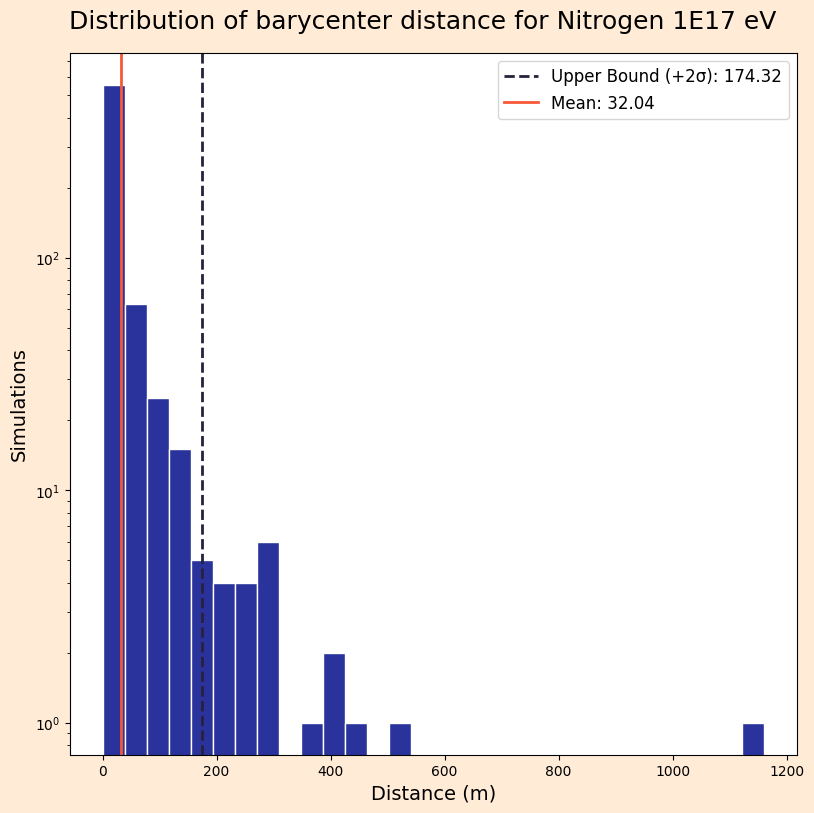

In [195]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Distribution of barycenter distance for ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_yscale('log')

# Calcula a média e o desvio padrão dos dados
mean = df['r_b'].mean()
std = df['r_b'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

plt.hist(df['r_b'], color = '#29339B', edgecolor = 'white', bins = 30)

# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Distance (m)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/barycenter_' + caminho_arquivo.split('/')[-1] + '_array.png', bbox_inches = 'tight')

[1.53773984e-15 3.32046404e-02]
[3.92671793 4.55391811 5.18190384 5.80910403 6.43708975]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_6688\1746835477.py:23: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_6688\1746835477.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
3.869935,15.0,14.954762,0.301589
4.603144,15.499687,15.538905,0.253026
5.222196,16.0,16.032101,0.200629
5.807941,16.499687,16.49876,0.005617
6.405517,17.0,16.974846,0.147963


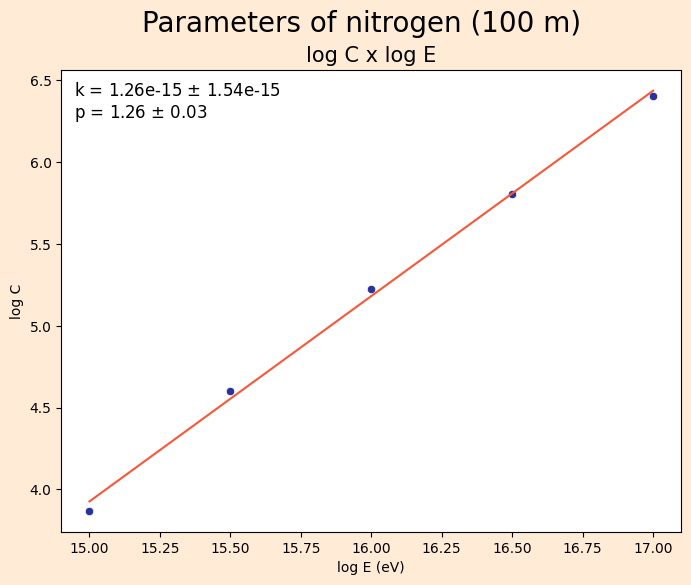

In [196]:
# Fit do nitrogênio

C = [7412, 4.01e+04, 1.668e+05, 6.426e+05, 2.544e+06]
E = [1E15, 3.16E15, 1E16, 3.16E16, 1E17]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of nitrogen (100 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_nitrogen, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_nitrogen))

ax.plot(logE, power(E,*coefficients_nitrogen), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_nitrogen[0],inc[0],coefficients_nitrogen[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_nitrogen[0]))/coefficients_nitrogen[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [197]:
k_nitrogen = coefficients_nitrogen[0] #- inc[0]
p_nitrogen = coefficients_nitrogen[1] #- inc[1]
c_nitrogen = parameters_df['C'] #- parameters_df['C_err']

E_photon = []
E_real = float(name.split(' ')[1])

erro_relativo = []
erro_absoluto = []

for i in range(len(c_nitrogen)):
    E = (c_nitrogen[i] / k_nitrogen) ** (1 / p_nitrogen)
    E_photon.append(E)
    
    # Calcular erro absoluto
    erro_abs = abs(E - E_real)
    erro_absoluto.append(erro_abs)
    
    # Calcular erro relativo (em porcentagem)
    erro_rel = (erro_abs / E_real) * 100
    erro_relativo.append(erro_rel)

data = {
    'E':E_photon,
    'Relative_error':erro_relativo,
    'Absolute_error':erro_absoluto
}

df3 = pl.DataFrame(data)
df3

E,Relative_error,Absolute_error
f64,f64,f64
2.0305e16,79.694685,7.9695e16
8.3032e16,16.967837,1.6968e16
1.7108e17,71.076134,7.1076e16
4.9272e16,50.728122,5.0728e16
1.0126e17,1.25522,1.2552e15
…,…,…
4.1939e16,58.061055,5.8061e16
3.2495e16,67.505095,6.7505e16
3.4018e16,65.981957,6.5982e16


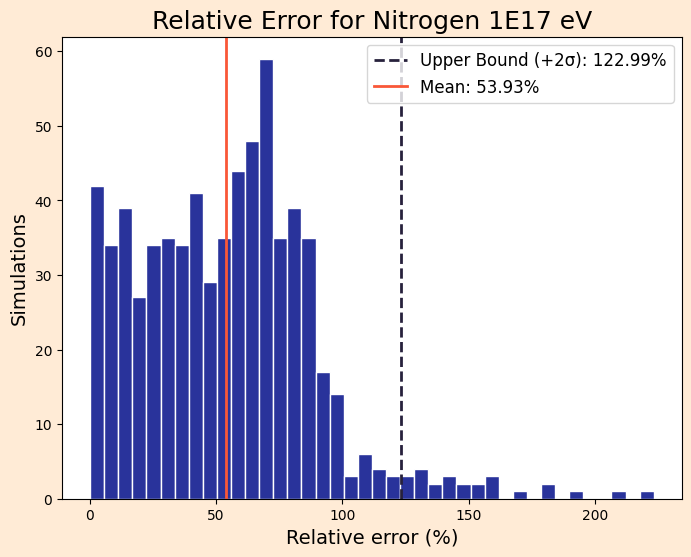

In [198]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(erro_relativo, color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('Relative Error (%)')
plt.title('Relative Error for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = df3['Relative_error'].mean()
std = df3['Relative_error'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}%')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}%')

# Personaliza o eixo e a legenda
ax.set_xlabel('Relative error (%)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() +'/energy_'+ caminho_arquivo.split('/')[-1] + '_array.png',bbox_inches = 'tight')

In [199]:
from uncertainties import ufloat
import uncertainties.umath as umath

k_value = coefficients_nitrogen[0]
k_error = inc[0]  
p_value = coefficients_nitrogen[1]
p_error = inc[1]  

k_proton = ufloat(k_value, k_error)
p_proton = ufloat(p_value, p_error)

c_protons = [ufloat(c, c_err) for c, c_err in zip(parameters_df['C'], parameters_df['C_err'])]

E_photon_with_errors = []

E_real = float(name.split(' ')[1])

for c in c_protons:
    E = (c / k_nitrogen) ** (1 / p_nitrogen)
    E_photon_with_errors.append(E)


E_nominal = [e.nominal_value for e in E_photon_with_errors]
E_error = [e.std_dev for e in E_photon_with_errors]

erro_absoluto = [abs(e.nominal_value - E_real) for e in E_photon_with_errors]
erro_relativo = [(erro / E_real) * 100 for erro in erro_absoluto]


data = {
    'E': E_nominal,
    'Propagated_uncertainty': E_error,
    'Absolute_error': erro_absoluto,
    'Relative_error': erro_relativo    
}

df3 = pl.DataFrame(data)

df3

E,Propagated_uncertainty,Absolute_error,Relative_error
f64,f64,f64,f64
2.0305e16,6.1233e15,7.9695e16,79.694685
8.3032e16,8.4055e15,1.6968e16,16.967837
1.7108e17,1.3885e16,7.1076e16,71.076134
4.9272e16,8.0476e15,5.0728e16,50.728122
1.0126e17,9.5753e15,1.2552e15,1.25522
…,…,…,…
4.1939e16,6.5553e15,5.8061e16,58.061055
3.2495e16,7.8599e15,6.7505e16,67.505095
3.4018e16,6.1225e15,6.5982e16,65.981957


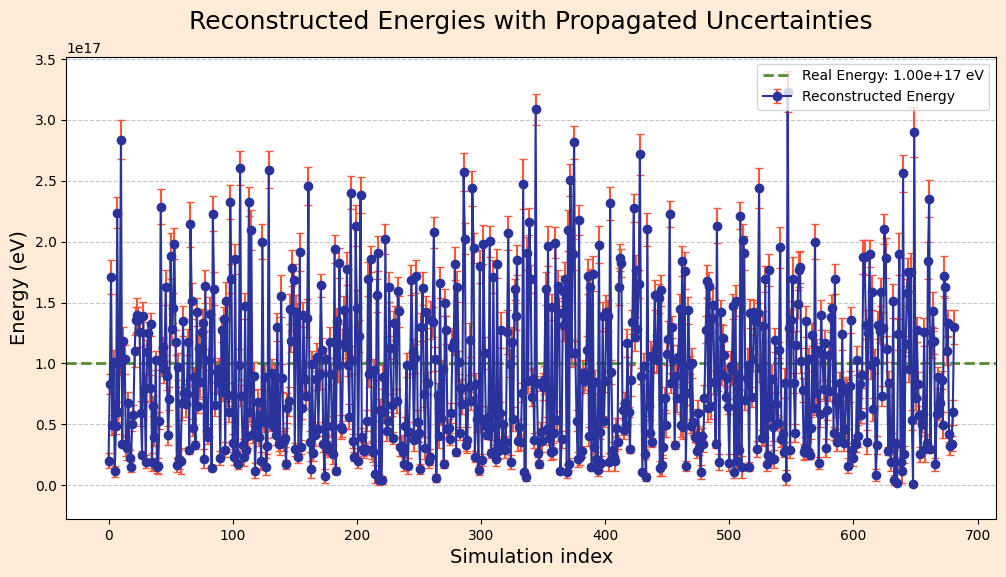

In [200]:
x = np.arange(len(E_nominal))  

plt.figure(figsize=(12, 6), facecolor='#FFEBD6')
ax = plt.gca()

plt.errorbar(
    x,
    E_nominal,
    yerr=E_error,
    fmt='-o',           
    color='#29339B',    
    ecolor='#F95738',   
    elinewidth=1.5,    
    capsize=3,          
    #alpha=0.7,          
    label='Reconstructed Energy'
)

plt.axhline(
    E_real,
    color='#548C2F',
    linestyle='--',
    linewidth=2,
    label=f'Real Energy: {E_real:.2e} eV'
)

plt.xlabel('Simulation index', size=14)
plt.ylabel('Energy (eV)', size=14)
plt.title('Reconstructed Energies with Propagated Uncertainties', size=18, pad=20)

# Adicionar legenda e grid
plt.legend(loc='upper right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.ylim(
    min(E_nominal) - 3 * np.mean(E_error),
    max(E_nominal) + 3 * np.mean(E_error)
)


plt.savefig('plots/' + name.split(' ')[0].lower() +'/energy_error_'+ caminho_arquivo.split('/')[-1] + '_array.png',bbox_inches = 'tight')